In [2]:
from google.colab import files
files.upload()

# 2. Set up the Kaggle API environment
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Smaller but similar dataset (~3.5GB)
!kaggle datasets download -d mohamedmustafa/real-life-violence-situations-dataset
!unzip -q real-life-violence-situations-dataset.zip -d ./mini_dataset

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mohamedmustafa/real-life-violence-situations-dataset
License(s): copyright-authors
100% 3.57G/3.58G [00:28<00:00, 103MB/s] 
100% 3.58G/3.58G [00:28<00:00, 135MB/s]


In [3]:
# 1. Unzip the dataset
!unzip -q real-life-violence-situations-dataset.zip -d ./dataset

# 2. Delete the zip to free up 3.5GB of space
!rm real-life-violence-situations-dataset.zip

import os
print(os.listdir('./dataset/Real Life Violence Dataset'))

['Violence', 'NonViolence']


In [4]:
import cv2
import numpy as np

def get_frames_from_video(video_path, target_frames=20, img_size=128):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    interval = max(1, total_frames // target_frames)

    frames = []

    for i in range(target_frames):
        # Set the 'camera' to the specific frame index
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * interval)
        ret, frame = cap.read()

        if ret:
            # Resize and Normalize (0 to 1)
            frame = cv2.resize(frame, (img_size, img_size))
            frame = frame / 255.0
            frames.append(frame)
        else:
            # If a frame fails to load, append a black frame to keep the shape consistent
            frames.append(np.zeros((img_size, img_size, 3)))

    cap.release()
    return np.array(frames)

In [5]:
import numpy as np
import cv2
import os

# Define paths based on the unzip folder
BASE_DIR = './dataset/Real Life Violence Dataset/'
categories = ['Violence', 'NonViolence']

X = []
y = []

# Loop through each category and grab a subset
for label, cat in enumerate(categories):
    folder_path = os.path.join(BASE_DIR, cat)
    video_files = os.listdir(folder_path)[:200] # Subset: 200 videos per class

    print(f"Processing {cat}...")
    for vid in video_files:
        path = os.path.join(folder_path, vid)
        frames = get_frames_from_video(path, target_frames=20)
        X.append(frames)
        y.append(label) # 0 for Violence, 1 for Non-Violence

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

print(f"Data shape: {X.shape}") # Should be (400, 20, 128, 128, 3)

Processing Violence...
Processing NonViolence...
Data shape: (400, 20, 128, 128, 3)


In [6]:
from sklearn.model_selection import train_test_split

# Shuffle and split: 80% for training, 20% for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

Training samples: 320
Validation samples: 80


In [7]:
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    LSTM,
    Bidirectional,
    TimeDistributed
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

def build_advanced_model(seq_len=20, img_size=128):
    # 1. Load MobileNetV2 without the top head
    base_cnn = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(img_size, img_size, 3))
    base_cnn.trainable = False  # Freeze the weights so we only train the BiLSTM

    model = models.Sequential([
        layers.Input(shape=(seq_len, img_size, img_size, 3)),

        # Apply MobileNet to every frame
        layers.TimeDistributed(base_cnn),

        layers.Bidirectional(layers.LSTM(128, return_sequences=False)),

        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_1 = build_advanced_model()
model_1.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 20, 1280)       │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │     1,442,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,717,313 (14.18 MB)

 Trainable params: 1,459,329 (5.57 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

early = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights=True
)

history = model_1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=4, # Small batch size because video data is heavy
    verbose=1,
    callbacks = [early]
)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 132s 913ms/step - accuracy: 0.6552 - loss: 0.6888 - val_accuracy: 0.8000 - val_loss: 0.5279
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 51s 640ms/step - accuracy: 0.7718 - loss: 0.4628 - val_accuracy: 0.8625 - val_loss: 0.3984
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 50s 630ms/step - accuracy: 0.8994 - loss: 0.2827 - val_accuracy: 0.8500 - val_loss: 0.3587
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 52s 647ms/step - accuracy: 0.9447 - loss: 0.1971 - val_accuracy: 0.8625 - val_loss: 0.3072
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 51s 636ms/step - accuracy: 0.9833 - loss: 0.1073 - val_accuracy: 0.8375 - val_loss: 0.3240
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 51s 635ms/step - accuracy: 0.9663 - loss: 0.0996 - val_accuracy: 0.8625 - val_loss: 0.2893
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 50s 630ms/step - accuracy: 0.9880 - loss: 0.0631 - val_accuracy: 0.8625 - val_loss: 0.3156
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 50s 621ms/step - accuracy: 0.9991 - loss: 0.0325 - val_acc

In [9]:
loss, accuracy = model_1.evaluate(X_val, y_val)
print(f"Final Validation Accuracy: {accuracy*100:.2f}%")
print(f"Final Validation Loss: {loss:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.8453 - loss: 0.3152
Final Validation Accuracy: 86.25%
Final Validation Loss: 0.2893


3/3 ━━━━━━━━━━━━━━━━━━━━ 48s 12s/step


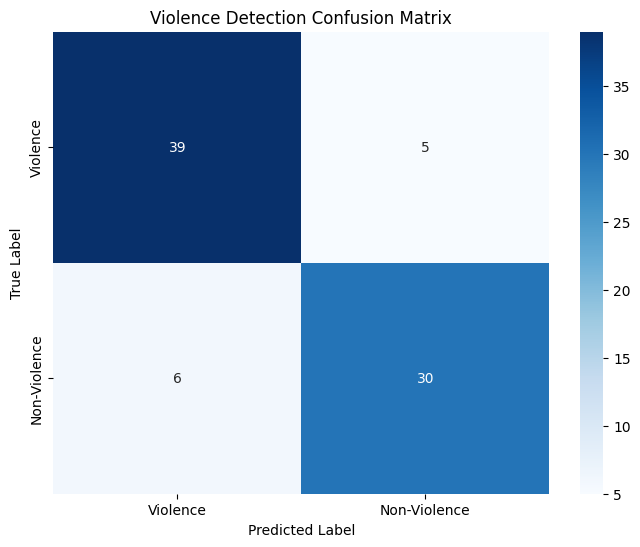


--- Detailed Classification Report ---
              precision    recall  f1-score   support

    Violence       0.87      0.89      0.88        44
Non-Violence       0.86      0.83      0.85        36

    accuracy                           0.86        80
   macro avg       0.86      0.86      0.86        80
weighted avg       0.86      0.86      0.86        80



In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Generate predictions from your validation set
# We use 0.5 as the threshold for binary classification
y_pred_probs = model_1.predict(X_val)
y_pred = (y_pred_probs > 0.5).astype("int32")

# 2. Compute the confusion matrix
cm = confusion_matrix(y_val, y_pred)

# 3. Plotting the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Violence', 'Non-Violence'],
            yticklabels=['Violence', 'Non-Violence'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Violence Detection Confusion Matrix')
plt.show()

# 4. Print detailed metrics (Precision, Recall, F1-Score)
print("\n--- Detailed Classification Report ---")
print(classification_report(y_val, y_pred, target_names=['Violence', 'Non-Violence']))

In [11]:
from google.colab import files

model_1.save('bilstm_model_1.keras')
files.download('bilstm_model_1.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>